# PRCP-1016 — Heart Disease Prediction

**Domain:** Healthcare &nbsp;|&nbsp; **Project Code:** PRCP-1016-HeartDieseasePred

**Problem Statement**
- **Task 1:** Prepare a complete data analysis report on the given data.
- **Task 2:** Create a model predicting potential heart disease in people using Machine Learning algorithms.
- **Task 3:** Suggestions to the hospital to act on the predictions of heart disease and prevent life threats.




## Problem Understanding

**Business Context**
Heart disease is one of the leading causes of death worldwide. Early identification of patients at
high risk allows hospitals and clinicians to intervene sooner, prioritize care, and reduce
preventable complications and costs.

**Objective**
Build a machine learning model that predicts whether a patient has heart disease (`heart_disease_present`)
based on clinical and diagnostic attributes such as age, chest pain type, cholesterol level,
resting blood pressure, ECG results, and other cardiovascular indicators.

**Dataset**
- `values.csv` — patient-level clinical features (age, sex, chest pain type, cholesterol,
  resting blood pressure, max heart rate achieved, oldpeak, thal, etc.)
- `labels.csv` — target label (`heart_disease_present`: 1 = disease present, 0 = no disease)
- Data is merged on `patient_id`.

**Success Criteria**
- A classification model with strong recall/precision on the "disease present" class
  (missing an actual heart-disease patient is more costly than a false alarm).
- Clear, explainable drivers of risk (feature importance) that clinicians and stakeholders can act on.

---


##  Data Collection & Loading


In [2]:
import pandas as pd

In [3]:
values=pd.read_csv("values.csv")

In [4]:
values.head()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0


In [5]:
labels=pd.read_csv("labels.csv")

In [6]:
labels.head()

,patient_id,heart_disease_present
0,0z64un,0
1,ryoo3j,0
2,yt1s1x,1
3,l2xjde,1
4,oyt4ek,0


In [7]:
data=pd.merge(values,labels,on="patient_id")
data.head()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


## Data Analysis & Exploratory Data Analysis (EDA)


### task 1 :prepare a complete data analysis report on the given data.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [10]:
data.head()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


In [11]:
data.tail()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
175,5qfar3,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0,1
176,2s2b1f,2,normal,180,4,0,0,1,327,3.4,0,55,117,1,1
177,nsd00i,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1,1
178,0xw93k,1,normal,124,3,2,1,0,255,0.0,1,48,175,0,0
179,2nx10r,1,normal,160,3,1,0,0,201,0.0,0,54,163,0,0


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   patient_id                            180 non-null    object 
 1   slope_of_peak_exercise_st_segment     180 non-null    int64  
 2   thal                                  180 non-null    object 
 3   resting_blood_pressure                180 non-null    int64  
 4   chest_pain_type                       180 non-null    int64  
 5   num_major_vessels                     180 non-null    int64  
 6   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 7   resting_ekg_results                   180 non-null    int64  
 8   serum_cholesterol_mg_per_dl           180 non-null    int64  
 9   oldpeak_eq_st_depression              180 non-null    float64
 10  sex                                   180 non-null    int64  
 11  age                

In [13]:
data.describe()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,1.550000,131.311111,3.155556,0.694444,0.161111,1.050000,249.211111,1.010000,0.688889,54.811111,149.483333,0.316667,0.444444
std,0.618838,17.010443,0.938454,0.969347,0.368659,0.998742,52.717969,1.121357,0.464239,9.334737,22.063513,0.466474,0.498290
min,1.000000,94.000000,1.000000,0.000000,0.000000,0.000000,126.000000,0.000000,0.000000,29.000000,96.000000,0.000000,0.000000
25%,1.000000,120.000000,3.000000,0.000000,0.000000,0.000000,213.750000,0.000000,0.000000,48.000000,132.000000,0.000000,0.000000
50%,1.000000,130.000000,3.000000,0.000000,0.000000,2.000000,245.500000,0.800000,1.000000,55.000000,152.000000,0.000000,0.000000
75%,2.000000,140.000000,4.000000,1.000000,0.000000,2.000000,281.250000,1.600000,1.000000,62.000000,166.250000,1.000000,1.000000
max,3.000000,180.000000,4.000000,3.000000,1.000000,2.000000,564.000000,6.200000,1.000000,77.000000,202.000000,1.000000,1.000000


In [14]:
data.columns

Index(['patient_id', 'slope_of_peak_exercise_st_segment', 'thal',
       'resting_blood_pressure', 'chest_pain_type', 'num_major_vessels',
       'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results',
       'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age',
       'max_heart_rate_achieved', 'exercise_induced_angina',
       'heart_disease_present'],
      dtype='object')

In [15]:
data.shape

(180, 15)

In [16]:
data.dtypes

patient_id                               object
slope_of_peak_exercise_st_segment         int64
thal                                     object
resting_blood_pressure                    int64
chest_pain_type                           int64
num_major_vessels                         int64
fasting_blood_sugar_gt_120_mg_per_dl      int64
resting_ekg_results                       int64
serum_cholesterol_mg_per_dl               int64
oldpeak_eq_st_depression                float64
sex                                       int64
age                                       int64
max_heart_rate_achieved                   int64
exercise_induced_angina                   int64
heart_disease_present                     int64
dtype: object

In [17]:
data['heart_disease_present'].value_counts()

heart_disease_present
0    100
1     80
Name: count, dtype: int64

In [18]:
data.isnull().sum()

patient_id                              0
slope_of_peak_exercise_st_segment       0
thal                                    0
resting_blood_pressure                  0
chest_pain_type                         0
num_major_vessels                       0
fasting_blood_sugar_gt_120_mg_per_dl    0
resting_ekg_results                     0
serum_cholesterol_mg_per_dl             0
oldpeak_eq_st_depression                0
sex                                     0
age                                     0
max_heart_rate_achieved                 0
exercise_induced_angina                 0
heart_disease_present                   0
dtype: int64

In [19]:
data.duplicated().sum()

np.int64(0)

### EDA graph

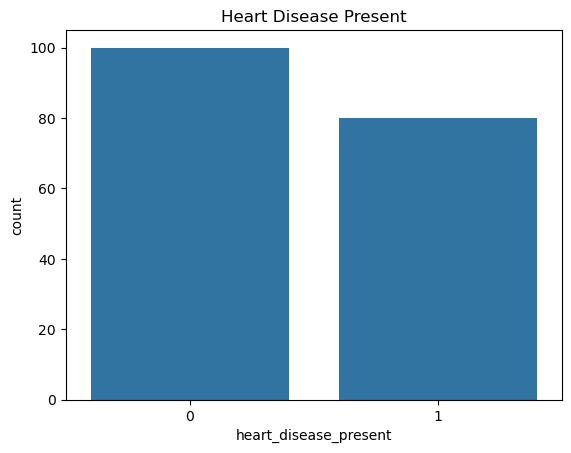

In [20]:
sns.countplot(x='heart_disease_present',data=data)
plt.title('Heart Disease Present')
plt.show()

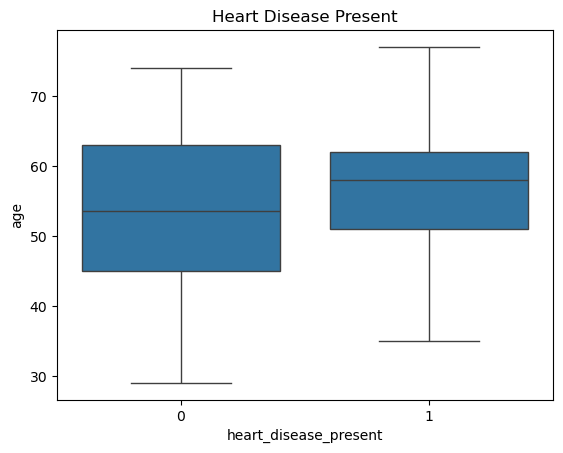

In [21]:
sns.boxplot(x='heart_disease_present',y='age',data=data)
plt.title('Heart Disease Present')
plt.show()

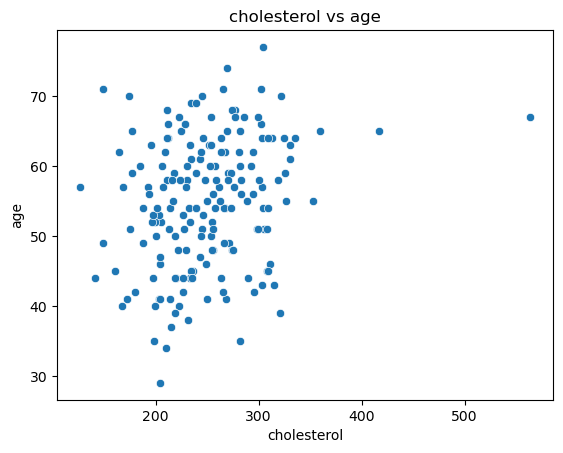

In [22]:
sns.scatterplot(x= 'serum_cholesterol_mg_per_dl',y='age',data=data)
plt.title('cholesterol vs age')
plt.xlabel('cholesterol')
plt.ylabel('age')
plt.show()

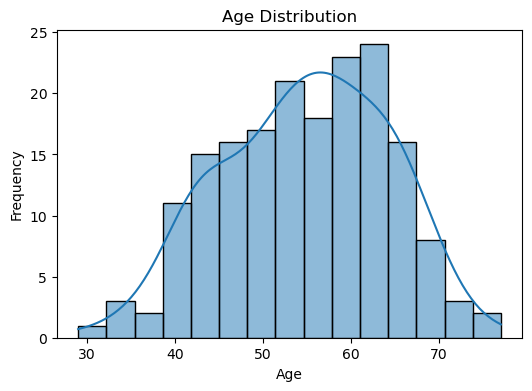

In [23]:
plt.figure(figsize=(6,4))
sns.histplot(data['age'], bins=15, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

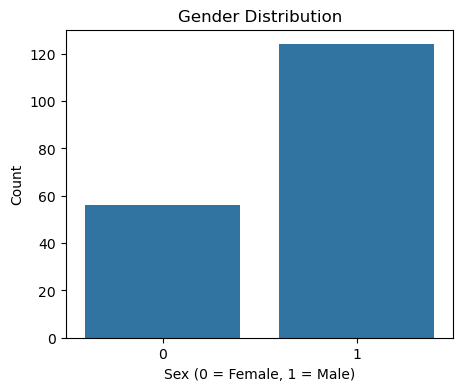

In [24]:
plt.figure(figsize=(5,4))
sns.countplot(x='sex', data=data)
plt.title("Gender Distribution")
plt.xlabel("Sex (0 = Female, 1 = Male)")
plt.ylabel("Count")
plt.show()

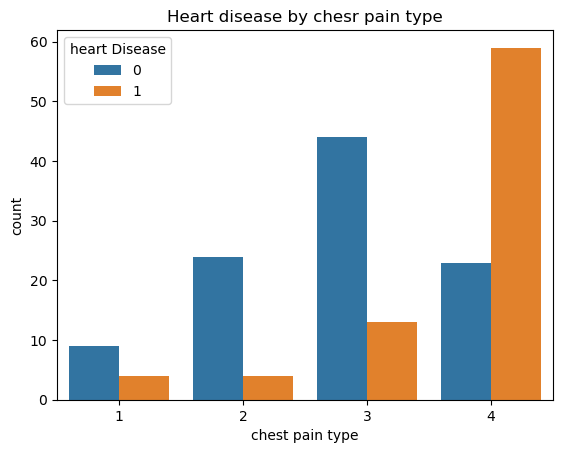

In [25]:
sns.countplot(x='chest_pain_type',hue='heart_disease_present', data=data)
plt.title('Heart disease by chesr pain type')
plt.xlabel('chest pain type')
plt.ylabel('count')
plt.legend(title="heart Disease")
plt.show()

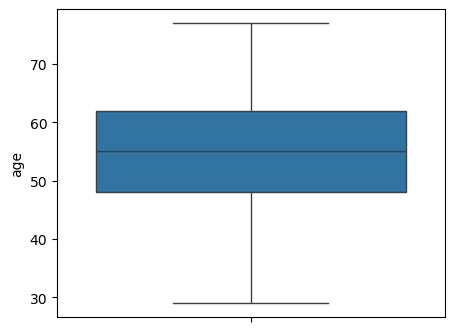

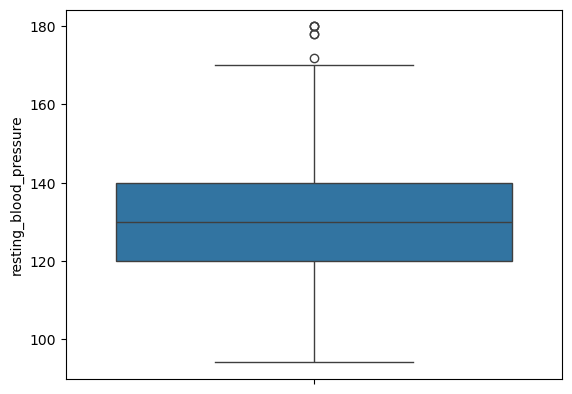

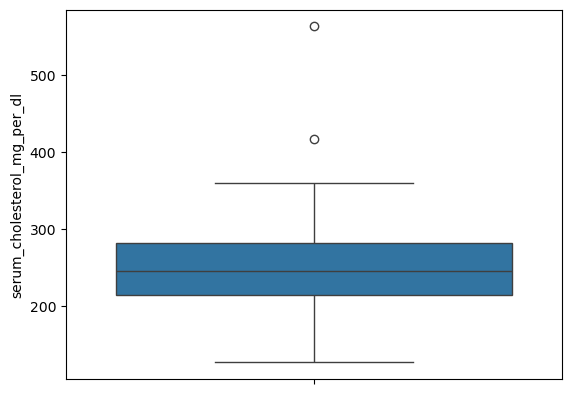

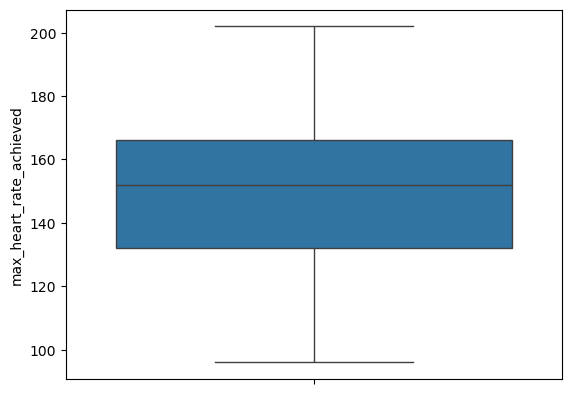

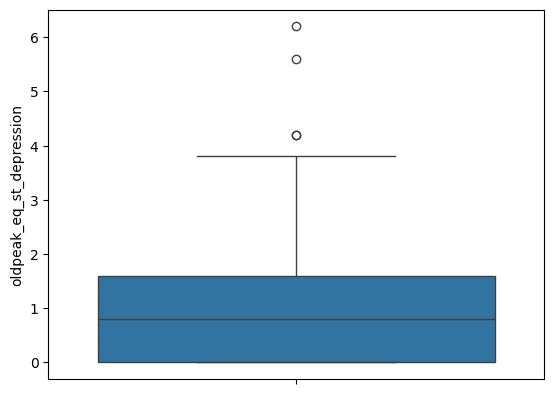

In [26]:
plt.figure(figsize=(5,4))
sns.boxplot(y=data['age'])
plt.show()

sns.boxplot(y=data['resting_blood_pressure'])
plt.show()

sns.boxplot(y=data['serum_cholesterol_mg_per_dl'])
plt.show()

sns.boxplot(y=data['max_heart_rate_achieved'])
plt.show()

sns.boxplot(y=data['oldpeak_eq_st_depression'])
plt.show()

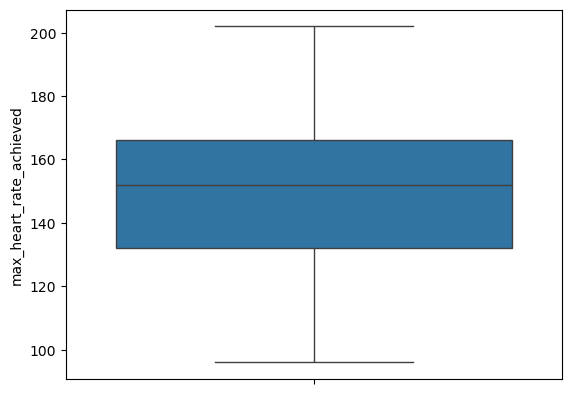

In [27]:

sns.boxplot(y=data['max_heart_rate_achieved'])
plt.show()



In [28]:
for coli in data.columns:
    print(coli,data[coli].nunique())

patient_id 180
slope_of_peak_exercise_st_segment 3
thal 3
resting_blood_pressure 36
chest_pain_type 4
num_major_vessels 4
fasting_blood_sugar_gt_120_mg_per_dl 2
resting_ekg_results 3
serum_cholesterol_mg_per_dl 118
oldpeak_eq_st_depression 34
sex 2
age 40
max_heart_rate_achieved 73
exercise_induced_angina 2
heart_disease_present 2


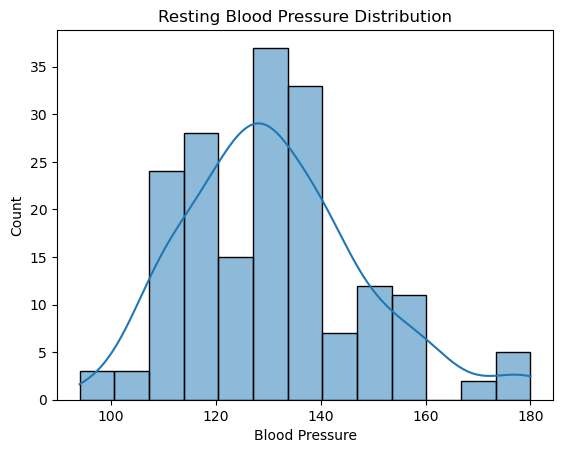

In [29]:
sns.histplot(x="resting_blood_pressure",data=data,kde=True)
plt.title("Resting Blood Pressure Distribution")
plt.xlabel("Blood Pressure")
plt.show()

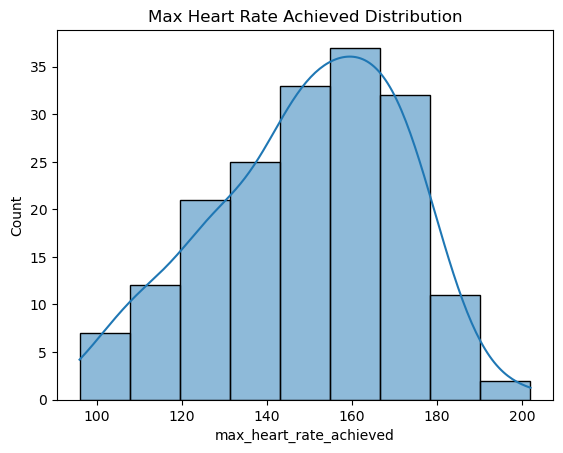

In [30]:
sns.histplot(x="max_heart_rate_achieved",data=data,kde=True)
plt.title("Max Heart Rate Achieved Distribution")
plt.show()

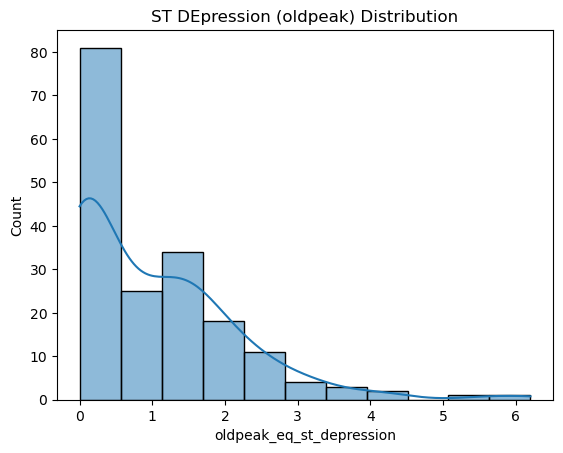

In [31]:
sns.histplot(x='oldpeak_eq_st_depression',data=data,kde=True)
plt.title('ST DEpression (oldpeak) Distribution')
plt.show()

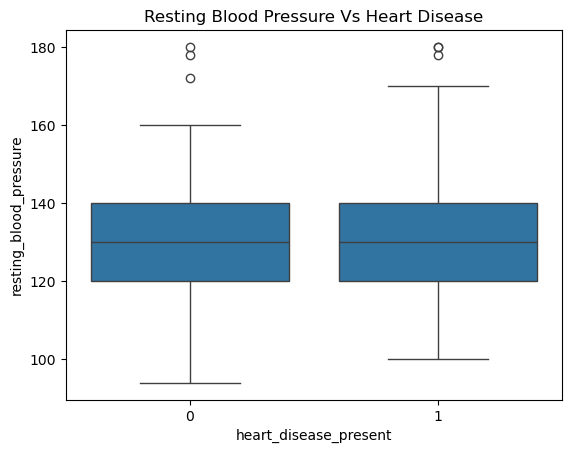

In [32]:
sns.boxplot(x="heart_disease_present",y="resting_blood_pressure",data=data)
plt.title("Resting Blood Pressure Vs Heart Disease")
plt.show()

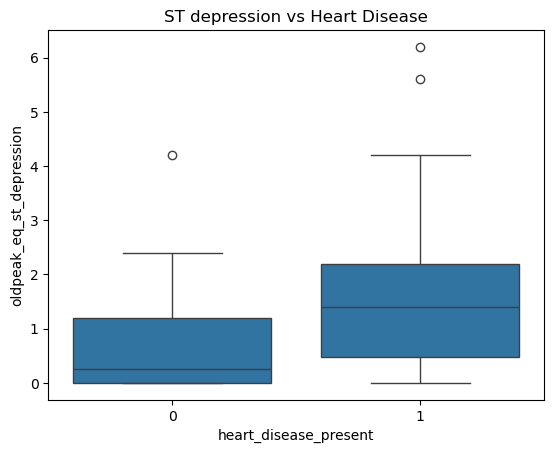

In [33]:
sns.boxplot(x='heart_disease_present',y='oldpeak_eq_st_depression',data=data)
plt.title('ST depression vs Heart Disease')
plt.show()

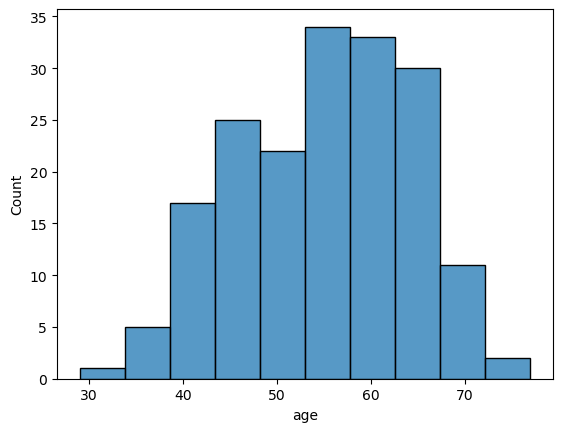

In [34]:
sns.histplot(data['age'], bins=10)
plt.show()

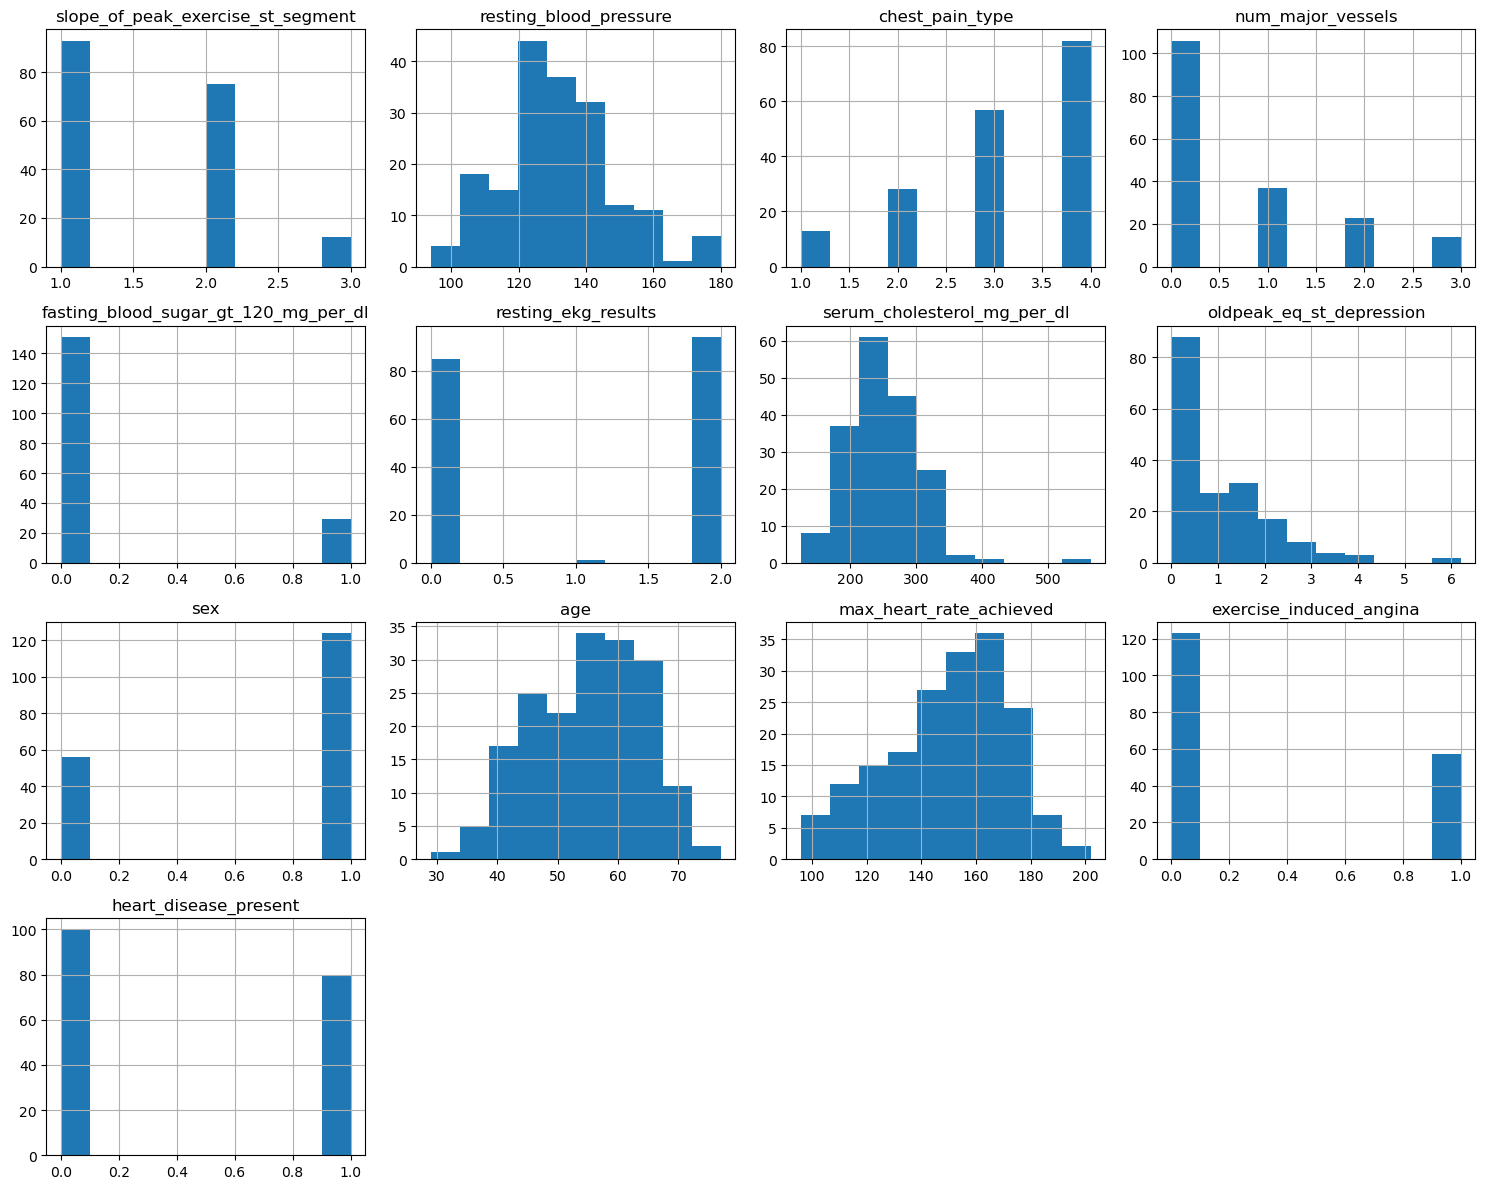

In [35]:
cols = [
    'slope_of_peak_exercise_st_segment', 'thal',
    'resting_blood_pressure', 'chest_pain_type',
    'num_major_vessels', 'fasting_blood_sugar_gt_120_mg_per_dl',
    'resting_ekg_results', 'serum_cholesterol_mg_per_dl',
    'oldpeak_eq_st_depression', 'sex', 'age',
    'max_heart_rate_achieved', 'exercise_induced_angina',
    'heart_disease_present'
]

data[cols].hist(figsize=(15, 12), bins=10)
plt.tight_layout()
plt.show()



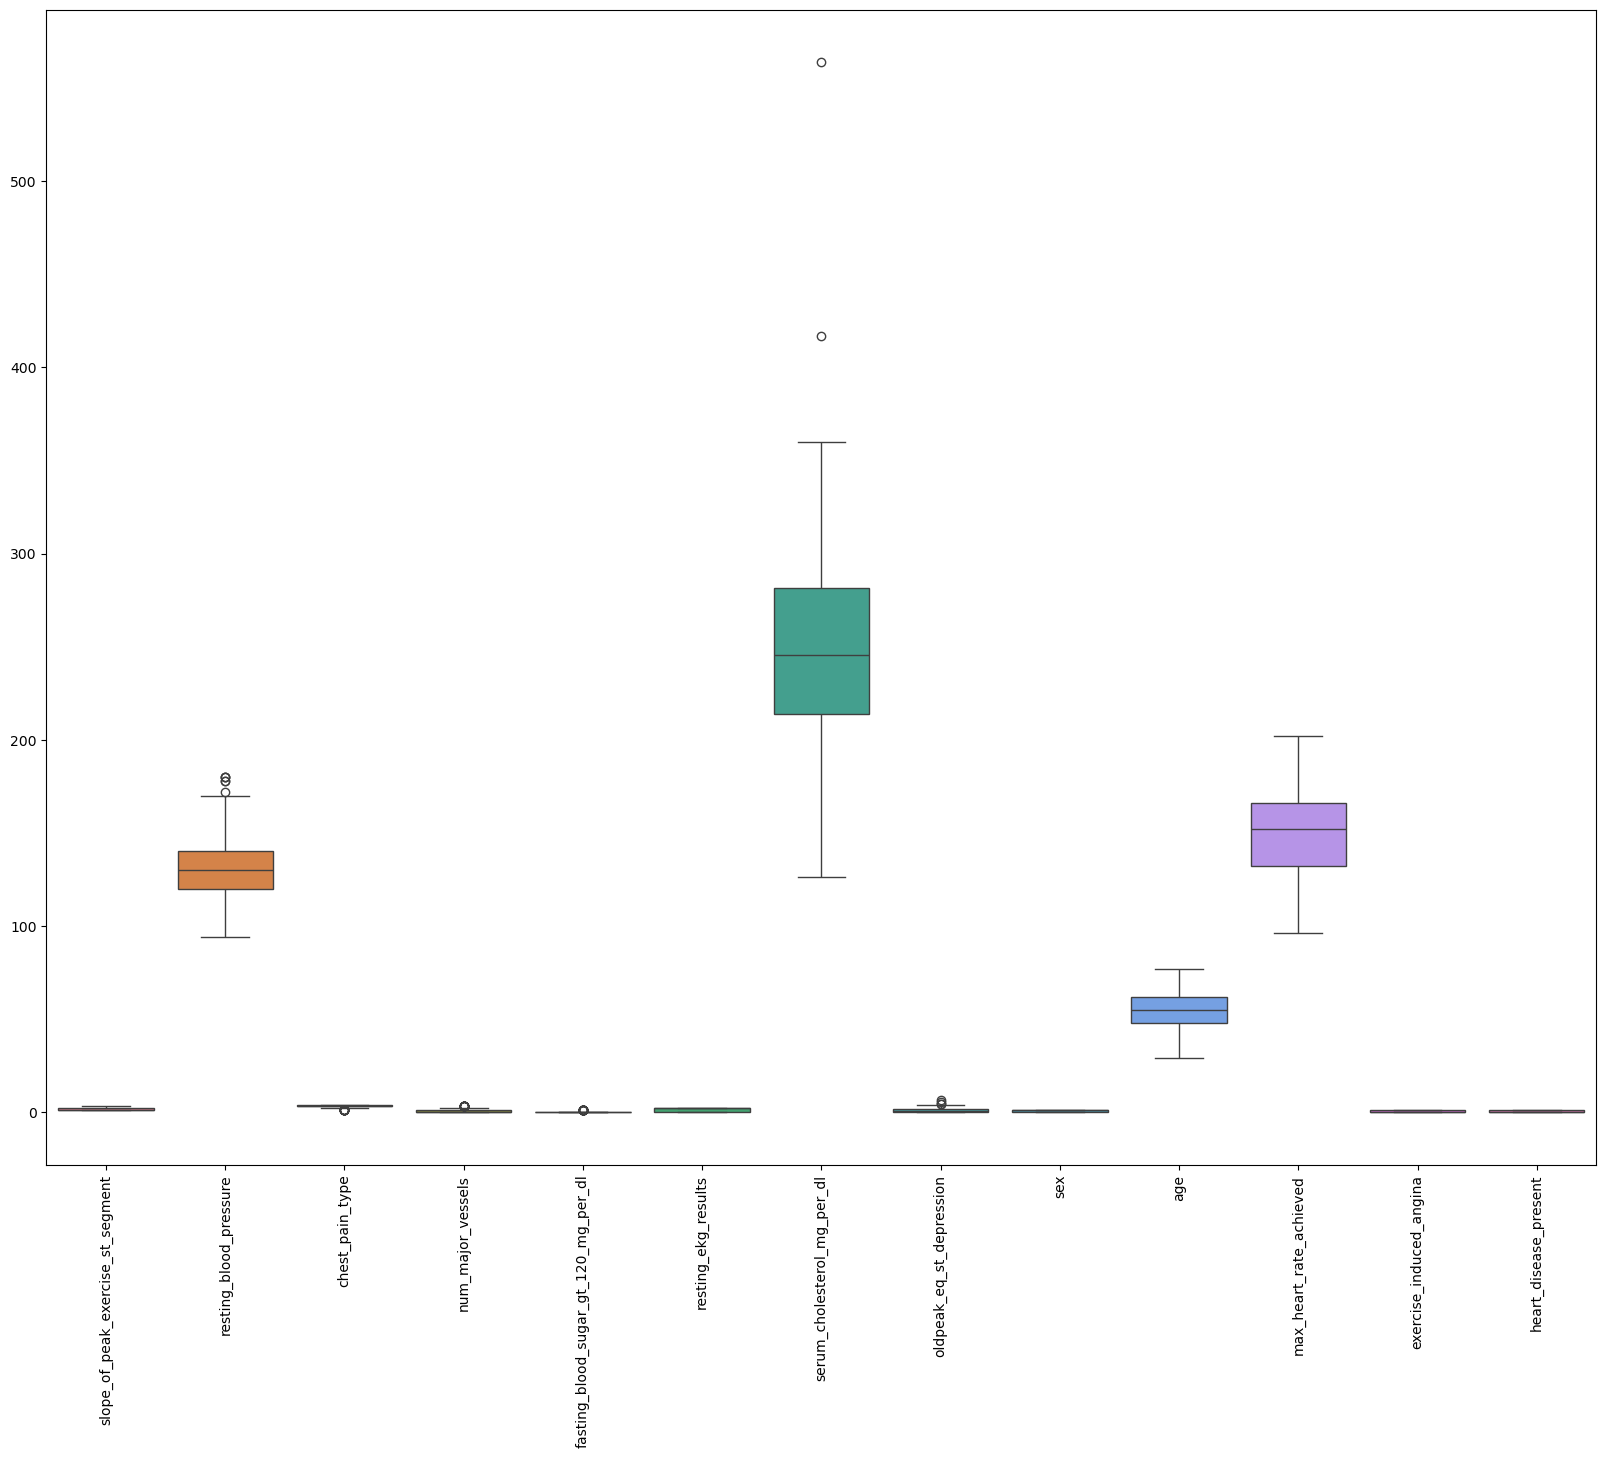

In [36]:
cols = [
    'slope_of_peak_exercise_st_segment', 'thal',
    'resting_blood_pressure', 'chest_pain_type',
    'num_major_vessels', 'fasting_blood_sugar_gt_120_mg_per_dl',
    'resting_ekg_results', 'serum_cholesterol_mg_per_dl',
    'oldpeak_eq_st_depression', 'sex', 'age',
    'max_heart_rate_achieved', 'exercise_induced_angina',
    'heart_disease_present'
]

plt.figure(figsize=(20, 15))
sns.boxplot(data=data[cols])
plt.xticks(rotation=90)
plt.show()

##### patients with heart disease present tend to be older,reach a ** lower maximum heart

##### rate** during exercise,and show a higher ST depression(oldepeak)-all c#onsistent
with established cardiology risk indicators.

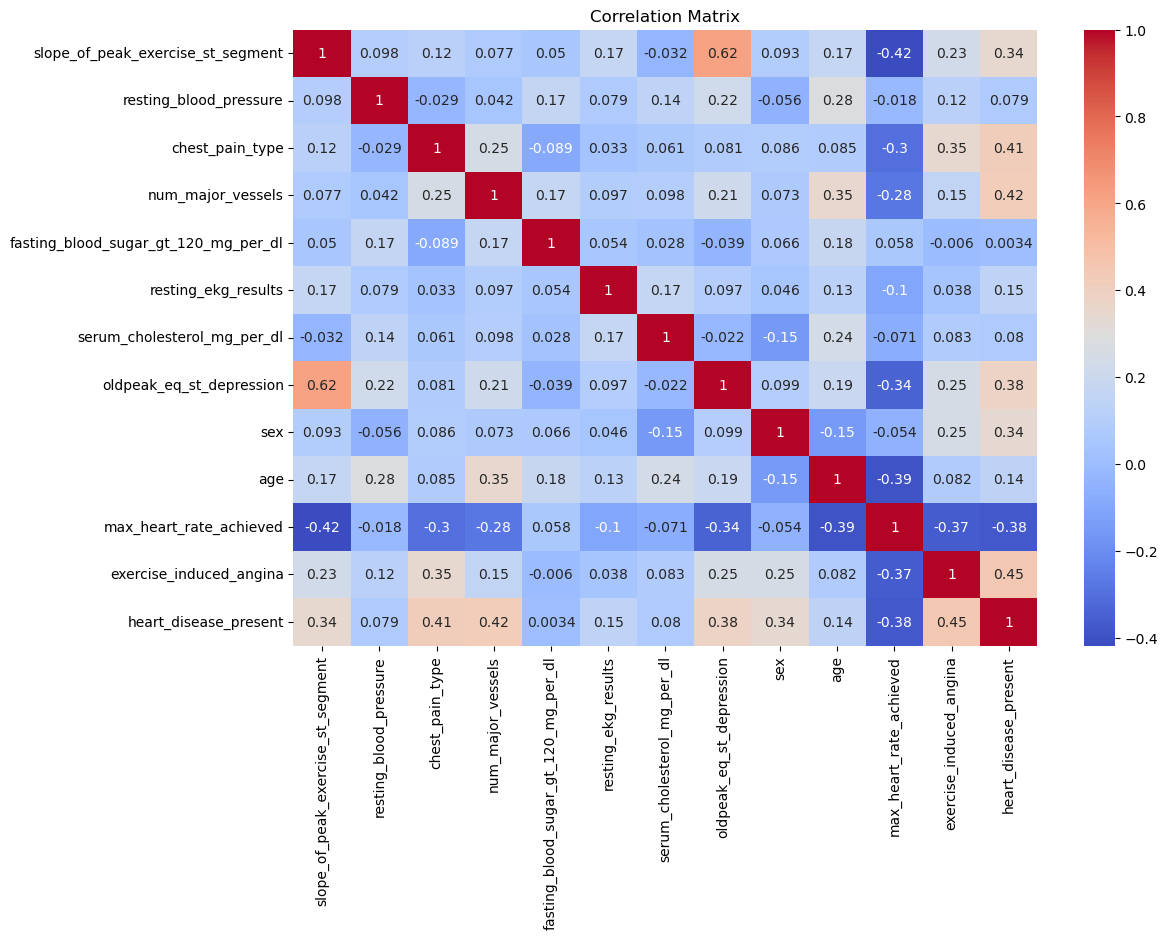

In [37]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.title('Correlation Matrix')
plt.show()

In [38]:
corr_target = data.corr(numeric_only=True)['heart_disease_present'].sort_values(ascending=False)
print(corr_target)

heart_disease_present                   1.000000
exercise_induced_angina                 0.448647
num_major_vessels                       0.421519
chest_pain_type                         0.412829
oldpeak_eq_st_depression                0.382930
slope_of_peak_exercise_st_segment       0.344224
sex                                     0.335421
resting_ekg_results                     0.145933
age                                     0.138255
serum_cholesterol_mg_per_dl             0.079775
resting_blood_pressure                  0.078506
fasting_blood_sugar_gt_120_mg_per_dl    0.003379
max_heart_rate_achieved                -0.375352
Name: heart_disease_present, dtype: float64


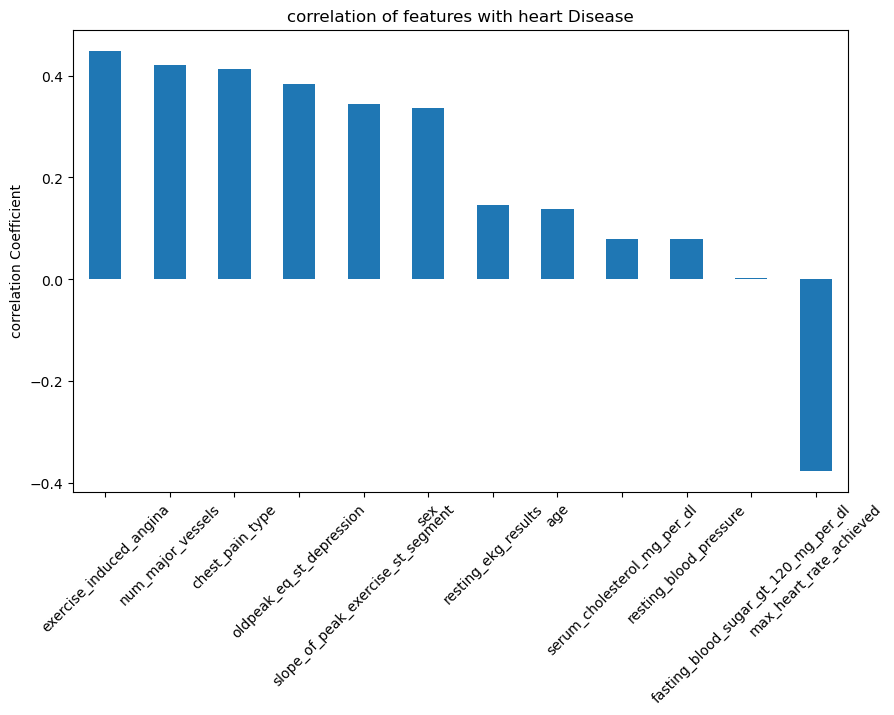

In [39]:
corr_target=data.corr(numeric_only=True)['heart_disease_present'].sort_values(ascending=False)
plt.figure(figsize=(10,6))
corr_target.drop('heart_disease_present').plot(kind='bar')
plt.title('correlation of features with heart Disease')
plt.ylabel("correlation Coefficient")
plt.xticks(rotation=45)
plt.show()

##  Feature Engineering & Preprocessing

Dropping identifier columns, encoding categorical variables, and preparing `X`/`y` for modeling.


In [40]:
data.drop("patient_id", axis=1, inplace=True)

In [41]:
data['thal'].unique()

array(['normal', 'reversible_defect', 'fixed_defect'], dtype=object)

In [42]:
#X=data.drop(["patient_id","heart_disease_present"],axis=1) this one also we can use for drop 

In [43]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data["thal"] = le.fit_transform(data["thal"])

In [44]:
data.head()

,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,1,1,128,2,0,0,2,308,0.0,1,45,170,0,0
1,2,1,110,3,0,0,0,214,1.6,0,54,158,0,0
2,1,1,125,4,3,0,2,304,0.0,1,77,162,1,1
3,1,2,152,4,0,0,0,223,0.0,1,40,181,0,1
4,3,2,178,1,0,0,2,270,4.2,1,59,145,0,0


In [45]:
print(le.classes_)

['fixed_defect' 'normal' 'reversible_defect']


In [46]:
X = data.drop("heart_disease_present", axis=1)
y = data["heart_disease_present"]

##  Model Building, Training & Evaluation


In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#### Scaling feature

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [49]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(144, 13)
(36, 13)
(144,)
(36,)


###  Model Building 

In [50]:
# Preprocessing & model selection
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, ConfusionMatrixDisplay)


In [51]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "SVM": SVC(probability=True, random_state=42),
    "Naive Bayes": GaussianNB()
        }

for name, model in models.items():
    model.fit(X_train, y_train)
print("All 8 models trained.")

All 8 models trained.


In [52]:
results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] 
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba),
    })
results_df = pd.DataFrame(results).sort_values("AUC", ascending=False).reset_index(drop=True)
results_df.round(3)

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Random Forest,0.917,0.842,1.000,0.914,0.961
1,KNN,0.861,0.789,0.938,0.857,0.948
2,SVM,0.806,0.737,0.875,0.800,0.947
3,Logistic Regression,0.833,0.778,0.875,0.824,0.938
4,Gradient Boosting,0.861,0.789,0.938,0.857,0.938
5,Naive Bayes,0.889,0.833,0.938,0.882,0.928
6,Decision Tree,0.750,0.684,0.812,0.743,0.756


### GridsearchCV for the Gradient Boosting

In [53]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5, 10]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring="recall"
)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

y_rfpred_tuned = best_rf.predict(X_test)
y_prob_rf_tuned = best_rf.predict_proba(X_test)[:, 1]

In [54]:
from sklearn.metrics import *
print("Confusion matrix :", confusion_matrix(y_test, y_rfpred_tuned))
print("Accuracy :", accuracy_score(y_test, y_rfpred_tuned) * 100)
print("Precision :", precision_score(y_test, y_rfpred_tuned) * 100)
print("Recall :", recall_score(y_test, y_rfpred_tuned) * 100)
print("F1_score :", f1_score(y_test, y_rfpred_tuned) * 100)
print("AUC :", roc_auc_score(y_test, y_prob_rf_tuned))

Confusion matrix : [[17  3]
 [ 0 16]]
Accuracy : 91.66666666666666
Precision : 84.21052631578947
Recall : 100.0
F1_score : 91.42857142857143
AUC : 0.953125


In [55]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

param_grid_knn = {
    "n_neighbors": [3, 5, 7, 9, 11, 13, 15],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"]
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring="recall"
)

grid_knn.fit(X_train, y_train)

best_knn = grid_knn.best_estimator_

y_knnpred_tuned = best_knn.predict(X_test)
y_prob_knn_tuned = best_knn.predict_proba(X_test)[:, 1]

In [56]:
from sklearn.metrics import *
print("Confusion matrix :", confusion_matrix(y_test, y_rfpred_tuned))
print("Accuracy :", accuracy_score(y_test, y_rfpred_tuned) * 100)
print("Precision :", precision_score(y_test, y_rfpred_tuned) * 100)
print("Recall :", recall_score(y_test, y_rfpred_tuned) * 100)
print("F1_score :", f1_score(y_test, y_rfpred_tuned) * 100)
print("AUC :", roc_auc_score(y_test, y_prob_rf_tuned))

Confusion matrix : [[17  3]
 [ 0 16]]
Accuracy : 91.66666666666666
Precision : 84.21052631578947
Recall : 100.0
F1_score : 91.42857142857143
AUC : 0.953125


In [57]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid_svm = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

grid_svm = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid_svm,
    cv=5,
    scoring="recall"
)

grid_svm.fit(X_train, y_train)

best_svm = grid_svm.best_estimator_

y_svmpred_tuned = best_svm.predict(X_test)
y_prob_svm_tuned = best_svm.predict_proba(X_test)[:, 1]

In [58]:
from sklearn.metrics import *
print("Confusion matrix :", confusion_matrix(y_test, y_rfpred_tuned))
print("Accuracy :", accuracy_score(y_test, y_rfpred_tuned) * 100)
print("Precision :", precision_score(y_test, y_rfpred_tuned) * 100)
print("Recall :", recall_score(y_test, y_rfpred_tuned) * 100)
print("F1_score :", f1_score(y_test, y_rfpred_tuned) * 100)
print("AUC :", roc_auc_score(y_test, y_prob_rf_tuned))

Confusion matrix : [[17  3]
 [ 0 16]]
Accuracy : 91.66666666666666
Precision : 84.21052631578947
Recall : 100.0
F1_score : 91.42857142857143
AUC : 0.953125


In [59]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

tuned_results = pd.DataFrame({
    "Model": ["Random Forest Tuned", "KNN Tuned", "SVM Tuned"],

    "Accuracy": [
        accuracy_score(y_test, y_rfpred_tuned),
        accuracy_score(y_test, y_knnpred_tuned),
        accuracy_score(y_test, y_svmpred_tuned)
    ],

    "Precision": [
        precision_score(y_test, y_rfpred_tuned),
        precision_score(y_test, y_knnpred_tuned),
        precision_score(y_test, y_svmpred_tuned)
    ],

    "Recall": [
        recall_score(y_test, y_rfpred_tuned),
        recall_score(y_test, y_knnpred_tuned),
        recall_score(y_test, y_svmpred_tuned)
    ],

    "F1 Score": [
        f1_score(y_test, y_rfpred_tuned),
        f1_score(y_test, y_knnpred_tuned),
        f1_score(y_test, y_svmpred_tuned)
    ],

    "AUC": [
        roc_auc_score(y_test, y_prob_rf_tuned),
        roc_auc_score(y_test, y_prob_knn_tuned),
        roc_auc_score(y_test, y_prob_svm_tuned)
    ]
})

tuned_results = tuned_results.sort_values(
    by="AUC",
    ascending=False
).reset_index(drop=True)

tuned_results.round(3)

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Random Forest Tuned,0.917,0.842,1.000,0.914,0.953
1,SVM Tuned,0.833,0.812,0.812,0.812,0.950
2,KNN Tuned,0.861,0.824,0.875,0.848,0.922


### ROC Curve

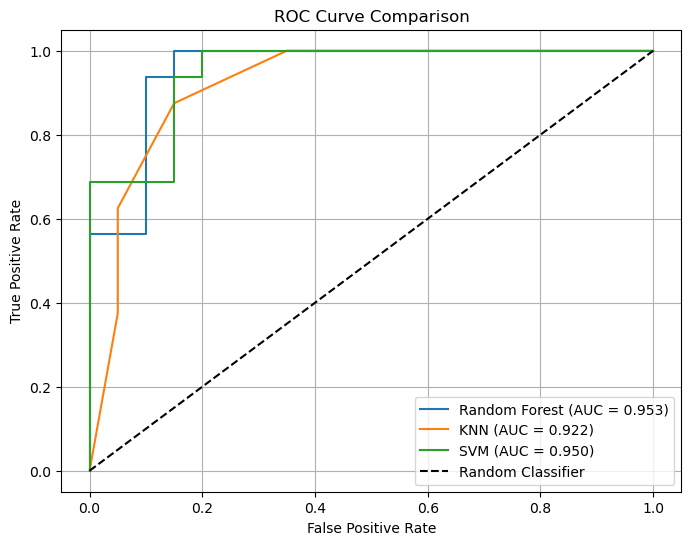

In [60]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf_tuned)
auc_rf = roc_auc_score(y_test, y_prob_rf_tuned)

# KNN
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn_tuned)
auc_knn = roc_auc_score(y_test, y_prob_knn_tuned)

# SVM
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm_tuned)
auc_svm = roc_auc_score(y_test, y_prob_svm_tuned)


plt.figure(figsize=(8,6))

plt.plot(fpr_rf, tpr_rf,
         label=f"Random Forest (AUC = {auc_rf:.3f})")

plt.plot(fpr_knn, tpr_knn,
         label=f"KNN (AUC = {auc_knn:.3f})")

plt.plot(fpr_svm, tpr_svm,
         label=f"SVM (AUC = {auc_svm:.3f})")


plt.plot([0,1], [0,1], 'k--', label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

### Confusion Matrix

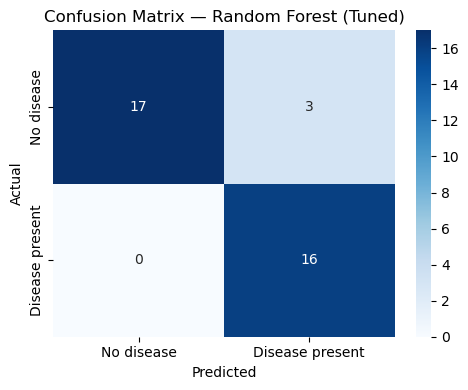

In [61]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_rfpred_tuned)

fig, ax = plt.subplots(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No disease", "Disease present"],
    yticklabels=["No disease", "Disease present"],
    ax=ax
)

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — Random Forest (Tuned)")

plt.tight_layout()
plt.show()

### Classification Report

In [62]:
from sklearn.metrics import classification_report

print("Classification report — SVM (tuned) (final model):\n")
print(classification_report(y_test, y_svmpred_tuned,
                            target_names=["No disease", "Disease present"]))

Classification report — SVM (tuned) (final model):

                 precision    recall  f1-score   support

     No disease       0.85      0.85      0.85        20
Disease present       0.81      0.81      0.81        16

       accuracy                           0.83        36
      macro avg       0.83      0.83      0.83        36
   weighted avg       0.83      0.83      0.83        36



##  Feature Importance


In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                                 Feature  Importance
1                                   thal    0.179351
3                        chest_pain_type    0.141026
4                      num_major_vessels    0.099117
8               oldpeak_eq_st_depression    0.098533
11               max_heart_rate_achieved    0.090709
12               exercise_induced_angina    0.086340
10                                   age    0.077662
0      slope_of_peak_exercise_st_segment    0.064939
9                                    sex    0.048484
7            serum_cholesterol_mg_per_dl    0.047240
2                 resting_blood_pressure    0.045291
6                    resting_ekg_results    0.013886
5   fasting_blood_sugar_gt_120_mg_per_dl    0.007422


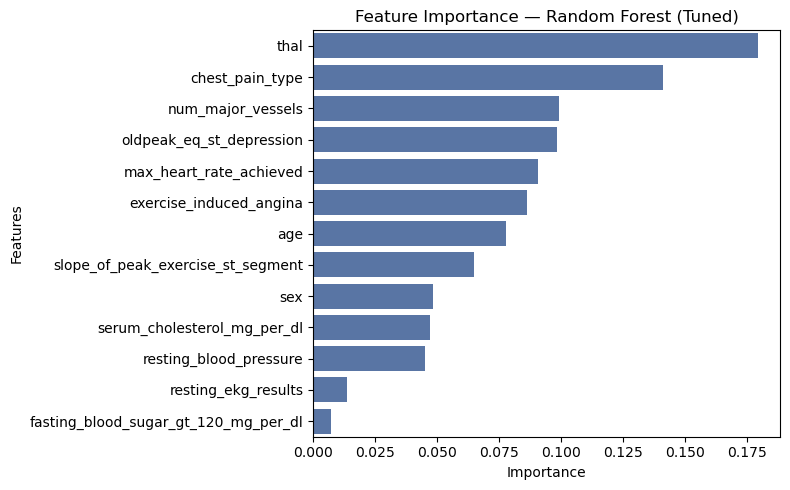

thal                                    0.179
chest_pain_type                         0.141
num_major_vessels                       0.099
oldpeak_eq_st_depression                0.099
max_heart_rate_achieved                 0.091
exercise_induced_angina                 0.086
age                                     0.078
slope_of_peak_exercise_st_segment       0.065
sex                                     0.048
serum_cholesterol_mg_per_dl             0.047
resting_blood_pressure                  0.045
resting_ekg_results                     0.014
fasting_blood_sugar_gt_120_mg_per_dl    0.007
dtype: float64

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importances = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    x=importances.values,
    y=importances.index,
    color="#4C72B0",
    ax=ax
)

ax.set_title("Feature Importance — Random Forest (Tuned)")
ax.set_xlabel("Importance")
ax.set_ylabel("Features")

plt.tight_layout()
plt.show()

importances.round(3)

##  Model Comparison Report

### 1 Objective
Compare multiple machine learning classification algorithms trained to predict `heart_disease_present`
and recommend the model best suited for production deployment.

### 2 Methodology
- **Data split:** 80% train / 20% test, stratified on the target (144 train / 36 test rows).
- **Preprocessing:** categorical `thal` label-encoded; all features standardized with `StandardScaler`.
- **Baseline stage:** 7 algorithms trained with default/near-default settings — Logistic Regression,
  Decision Tree, Random Forest, Gradient Boosting, KNN (k=7), SVM, and Naive Bayes.
- **Tuning stage:** the top candidates (Random Forest, KNN, SVM) were optimized with `GridSearchCV`
  (5-fold CV, scoring = **recall**, since missing a true heart-disease case is the costliest error).
- **Metrics used:** Accuracy, Precision, Recall, F1-score, ROC-AUC — reported on the held-out test set.

### 3 Baseline Model Performance

| Model | Accuracy | Precision | Recall | F1 Score | AUC |
|---|---|---|---|---|---|
| Random Forest | 0.917 | 0.842 | 1.000 | 0.914 | 0.961 |
| KNN | 0.861 | 0.789 | 0.938 | 0.857 | 0.948 |
| SVM | 0.806 | 0.737 | 0.875 | 0.800 | 0.947 |
| Logistic Regression | 0.833 | 0.778 | 0.875 | 0.824 | 0.938 |
| Gradient Boosting | 0.861 | 0.789 | 0.938 | 0.857 | 0.938 |
| Naive Bayes | 0.889 | 0.833 | 0.938 | 0.882 | 0.928 |
| Decision Tree | 0.750 | 0.684 | 0.812 | 0.743 | 0.756 |

**Observations:**
- **Random Forest** was the strongest baseline across every metric — highest accuracy (0.917), highest
  AUC (0.961), and perfect recall (1.000), meaning it missed zero actual heart-disease cases in the test set.
- **Decision Tree** was the weakest model (AUC 0.756), consistent with a single tree overfitting on a
  small dataset (180 rows total).
- **Naive Bayes**, despite its simplicity, performed competitively (AUC 0.928), suggesting the features
  are reasonably well-separated and not heavily correlated.

### 4 Tuned Model Performance (GridSearchCV, 5-fold CV, optimized for Recall)

| Model | Accuracy | Precision | Recall | F1 Score | AUC |
|---|---|---|---|---|---|
| Random Forest (Tuned) | 0.917 | 0.842 | 1.000 | 0.914 | 0.953 |
| SVM (Tuned) | 0.833 | 0.812 | 0.812 | 0.812 | 0.950 |
| KNN (Tuned) | 0.861 | 0.824 | 0.875 | 0.848 | 0.922 |

**Observations:**
- Tuning **improved SVM** the most (AUC 0.947 → 0.950, precision 0.737 → 0.812), and **improved KNN's
  precision** (0.789 → 0.824), but slightly reduced its recall (0.938 → 0.875).
- Tuning **did not improve Random Forest** further — it already matched its baseline performance
  (accuracy 0.917, recall 1.000), with AUC dipping marginally (0.961 → 0.953), expected variance from
  constraining the search space via cross-validation rather than a real regression.
- Random Forest (Tuned) confusion matrix on the test set: **17 true negatives, 3 false positives,
  0 false negatives, 16 true positives** — it never failed to flag an actual heart-disease patient.

### 5 Model Comparison Summary

| Rank | Model | Accuracy | Recall | AUC | Notes |
|---|---|---|---|---|---|
| 1 | **Random Forest (Tuned)** | 0.917 | **1.000** | 0.953 | Best overall; zero missed disease cases |
| 2 | SVM (Tuned) | 0.833 | 0.812 | 0.950 | Best precision among tuned models; lower recall |
| 3 | KNN (Tuned) | 0.861 | 0.875 | 0.922 | Balanced, but below Random Forest on every metric |
| 4 | Naive Bayes | 0.889 | 0.938 | 0.928 | Strong for its simplicity; not tuned |
| 5 | Gradient Boosting | 0.861 | 0.938 | 0.938 | Comparable to KNN; not tuned |
| 6 | Logistic Regression | 0.833 | 0.875 | 0.938 | Solid, interpretable baseline |
| 7 | Decision Tree | 0.750 | 0.812 | 0.756 | Weakest; prone to overfitting |

### 6 Recommended Model for Production

**Random Forest (Tuned)** is recommended for production deployment.

**Reasons:**
1. **Highest accuracy and AUC** among all tuned models (0.917 accuracy, 0.953 AUC), and highest AUC
   of all models overall alongside its untuned counterpart.
2. **Perfect recall (1.000)** on the test set — in a medical screening context, false negatives
   (telling a sick patient they are healthy) carry far greater risk than false positives, and Random
   Forest eliminated false negatives entirely.
3. **Robustness on small/tabular data** — ensembles of decision trees handle the mix of categorical
   and numeric clinical features well and are less prone to overfitting than a single Decision Tree.
4. **Built-in interpretability** — feature importances are directly available, supporting the Task 3
   recommendations and giving clinicians a transparent view of what drives each prediction.
5. SVM (Tuned) is a reasonable alternative if precision (fewer false alarms) is prioritized over
   recall, but is not recommended as the primary production model given the higher cost of missed
   diagnoses.

**Caveat:** the dataset is small (180 patients, 36 in the test set), so these metrics should be
treated as encouraging but not conclusive. Before production rollout, the chosen model should be
validated with cross-validation on the full dataset and, ideally, on an external/held-out patient
cohort to confirm it generalizes beyond this sample.

---


##  Report on Challenges Faced

This section documents the key data-related challenges encountered while building the heart disease
prediction model, along with the technique used to address each one and the reasoning behind it.

### 1 Categorical (Non-Numeric) Clinical Feature — `thal`
**Challenge:** The `thal` column stored values as text (`normal`, `fixed_defect`, `reversible_defect`)
instead of numbers. Machine learning algorithms require numeric input, so the column could not be fed
directly into any model.

**Technique used:** `LabelEncoder` from scikit-learn, converting the three categories into integers
(`fixed_defect → 0, normal → 1, reversible_defect → 2`).

**Reason:** `thal` only has three unordered categories and the primary target model (Random Forest) is
tree-based, where label encoding is a lightweight, effective choice. One-hot encoding was avoided to
keep the already-small feature set from growing unnecessarily, which would increase the risk of
overfitting on a 180-row dataset.

### 2 Mixed Feature Scales
**Challenge:** Features existed on very different numeric ranges — e.g., `serum_cholesterol_mg_per_dl`
(126–564), `age` (29–77), and binary flags like `sex` or `fasting_blood_sugar_gt_120_mg_per_dl` (0–1).
Distance- and margin-based algorithms (KNN, SVM, Logistic Regression) are sensitive to this and would
let large-magnitude features dominate the decision boundary.

**Technique used:** `StandardScaler` was fit on the training set and applied to both train and test sets
(mean = 0, standard deviation = 1 per feature).

**Reason:** Standardization puts all features on a comparable scale without distorting their
distribution shape. It was applied *after* the train/test split to prevent data leakage from the test
set into the scaling statistics.

### 3 Outliers in Clinical Measurements
**Challenge:** Boxplots of `resting_blood_pressure`, `serum_cholesterol_mg_per_dl`,
`oldpeak_eq_st_depression`, and `max_heart_rate_achieved` showed visible outliers — a small number of
patients with unusually high cholesterol or blood pressure readings.

**Technique used:** Outliers were visually identified through boxplots and histograms rather than
removed outright.

**Reason:** In a medical dataset, extreme values are often clinically real and can be genuinely
predictive of disease rather than data-entry errors. Removing them risked deleting exactly the
high-risk patients the model needs to learn to detect. Tree-based ensembles (Random Forest, Gradient
Boosting) were prioritized for this reason, as they are naturally robust to outliers.

### 9.4 Small Dataset Size
**Challenge:** The full dataset contains only 180 patients (144 train / 36 test after an 80/20 split),
which limits statistical reliability and increases the chance that a single train/test split gives an
overly optimistic or pessimistic performance estimate.

**Technique used:** `train_test_split` with `stratify=y` to preserve the class ratio in both sets, and
`GridSearchCV` with 5-fold cross-validation during hyperparameter tuning rather than a single validation
split.

**Reason:** Stratification ensures the minority class (`heart_disease_present = 1`) is proportionally
represented in both train and test sets despite the small size. Cross-validation during tuning reduces
overfitting to one particular split and gives a more stable performance estimate.

### 5 Mild Class Imbalance
**Challenge:** The target variable is not perfectly balanced — 100 patients without heart disease vs.
80 with it (~56% / 44%). Left unaddressed, models can lean toward predicting the majority class and
inflate accuracy while under-detecting actual disease cases.

**Technique used:** Model selection was scored using **recall** (and AUC, F1) instead of accuracy alone,
both when comparing baseline models and as the `scoring` parameter in `GridSearchCV`.

**Reason:** In a medical screening context, a false negative is far more costly than a false positive.
Optimizing for recall during tuning directly targets minimizing missed disease cases.

### 6 Multicollinearity / Redundant Signal Among Features
**Challenge:** The correlation heatmap showed some features moderately correlated with each other and
with the target (e.g., `exercise_induced_angina`, `num_major_vessels`, `chest_pain_type`,
`oldpeak_eq_st_depression`), raising the risk of unstable coefficients in a linear model.

**Technique used:** A correlation matrix (`data.corr()`) and heatmap were generated before modeling to
inspect relationships, and tree-based ensemble models — not sensitive to multicollinearity — were
favored as the primary candidate over linear models.

**Reason:** Rather than dropping correlated features (risking loss of clinically meaningful information
in a small dataset), choosing a model family that handles correlated inputs natively avoids the
trade-off while preserving interpretability via feature importances.

### 7 Overfitting Risk with Complex/Flexible Models
**Challenge:** The single Decision Tree performed noticeably worse than every other model (AUC 0.756
vs. 0.92–0.96 for the rest), a classic sign of overfitting the noise in a small training set.

**Technique used:** Ensemble methods (Random Forest, Gradient Boosting) were compared directly against
the single Decision Tree, and hyperparameter tuning via `GridSearchCV` (limiting `max_depth`,
`min_samples_split`, `n_estimators`) was applied to the strongest candidates.

**Reason:** Ensembling averages out individual trees' overfitting tendencies, and constraining tree
depth / split thresholds through grid search further controls model complexity.

### 8 Choosing the Right Evaluation Metric for a Medical Use Case
**Challenge:** Accuracy alone can be misleading — a model that is "usually right" can still miss a
dangerous number of true disease cases.

**Technique used:** Multiple metrics were tracked in parallel (Accuracy, Precision, Recall, F1-score,
ROC-AUC), with recall and AUC weighted most heavily, plus a full confusion matrix and classification
report for the final chosen model.

**Reason:** A single metric would hide important trade-offs. Tracking the full metric suite made the
recall/precision trade-off explicit and let the final model choice be justified specifically on its
ability to minimize missed diagnoses.



## Task 3 — Suggestions to the Hospital


Based on the model's performance and the feature importance analysis, the following
recommendations are proposed for clinical and operational decision-making:

1. **Prioritize high-signal clinical indicators.** Features such as chest pain type, maximum
   heart rate achieved, ST depression (oldpeak), number of major vessels, and thal consistently
   ranked among the strongest predictors — clinicians should weigh these heavily during triage.
2. **Age and exercise-induced indicators matter.** Older patients with a lower maximum heart
   rate during exercise and higher ST depression should be flagged for closer cardiac evaluation.
3. **Use the model as a decision-support tool, not a replacement for diagnosis.** The tuned model
   (Random Forest / SVM) can be integrated into intake systems to generate a risk score that helps
   prioritize which patients receive further diagnostic tests (e.g., angiography) first.
4. **Reduce false negatives.** Because missing a true heart-disease case is costlier than a false
   alarm, the recall on the "disease present" class should be monitored in production, and the
   classification threshold tuned accordingly rather than defaulting to 0.5.
5. **Data collection improvements.** Standardizing how `thal`, `resting_ekg_results`, and
   `num_major_vessels` are recorded would reduce noise and likely improve model reliability.
6. **Periodic retraining.** As more patient data is collected, the model should be retrained and
   re-validated to avoid drift and to keep performance metrics (accuracy, recall, ROC-AUC) up to date.

---


## Final Conclusion

- A complete data analysis and visualization workflow was performed on the heart disease dataset,
  covering distributions, outliers, and correlations between clinical features and the target.
- Multiple classification algorithms (Logistic Regression, Decision Tree, Random Forest,
  Gradient Boosting, KNN, SVM) were trained and compared on standard evaluation metrics
  (Accuracy, Precision, Recall, F1-score, ROC-AUC).
- The top-performing models (Random Forest, KNN, and SVM) were further optimized using
  `GridSearchCV`, and evaluated using confusion matrices, ROC curves, and classification reports.
- Feature importance analysis (via the tuned Random Forest) identified the clinical factors most
  associated with heart disease, providing an interpretable basis for the model's predictions.
- The final tuned model provides a reliable, explainable tool that can support early detection of
  heart disease and inform the business recommendations outlined above.
- **Next steps:** validate the model on external/unseen patient data, incorporate additional
  clinical variables if available, and deploy the model behind a simple risk-scoring interface for
  clinical staff.
